# WildTrace Pipeline Driver

This notebook is the current driver for the agentic WildTrace pipeline. It runs the DAG-style stage scripts in order so we can inspect outputs while keeping the same script boundaries that Airflow will use later.

Before running the notebook:
- run `uv sync` from the repo root
- start Ollama with `ollama serve`
- pull the configured local models
- make sure BioCLIP runs on a CUDA-capable GPU machine for bronze enrichment
- create `.env` from `.env.example` if you need custom model or host settings


In [1]:
from collections import Counter
from pathlib import Path
import json
import subprocess

import yaml
from IPython.display import SVG, display
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "scripts").exists() and (parent / "configs").exists():
            REPO_ROOT = parent
            break

SCRIPTS_DIR = REPO_ROOT / 'scripts'
CONFIG_DIR = REPO_ROOT / 'configs'
PYTHON = REPO_ROOT / '.venv' / 'bin' / 'python'

if not PYTHON.exists():
    raise FileNotFoundError(f"{PYTHON} not found. Run `uv sync` from {REPO_ROOT} first.")

print("repo_root =", REPO_ROOT)
print("python =", PYTHON)
print("scripts_dir =", SCRIPTS_DIR)
print("config_dir =", CONFIG_DIR)

RUN_FETCH_IDEMPOTENCY_CHECK = False
print('RUN_FETCH_IDEMPOTENCY_CHECK =', RUN_FETCH_IDEMPOTENCY_CHECK)


repo_root = /home/shravan/Workspace/WildTrace
python = /home/shravan/Workspace/WildTrace/.venv/bin/python
scripts_dir = /home/shravan/Workspace/WildTrace/scripts
config_dir = /home/shravan/Workspace/WildTrace/configs


In [2]:
def run_stage(script_name: str):
    script = SCRIPTS_DIR / script_name
    cmd = [str(PYTHON), str(script), '--repo-root', str(REPO_ROOT), '--config-dir', str(CONFIG_DIR)]
    print('Running:', ' '.join(cmd))
    return subprocess.run(cmd, check=True)


def load_ndjson(path: Path):
    if not path.exists():
        return []
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

## Inspect Configs

Tune these first before running a larger fetch.

In [3]:
for name in ['datasets.yaml', 'storage.yaml', 'quality.yaml', 'models.yaml', 'export.yaml']:
    path = CONFIG_DIR / name
    print(f'\n## {name}')
    print(yaml.safe_dump(yaml.safe_load(path.read_text()), sort_keys=False))


## datasets.yaml
task_type: drawing
source_dataset: openimages
categories:
- name: Cat
  limit: 100
- name: Dog
  limit: 100
- name: Horse
  limit: 100
- name: Bird
  limit: 100
- name: Butterfly
  limit: 100
- name: Fish
  limit: 100
fetch:
  source_mode: official
  records_path: null
  records: []
  timeout_seconds: 30
  user_agent: WildTraceETL/0.1
  manifest_path: raw_data/bronze/manifests/openimages_fetch.ndjson
  latest_view_path: raw_data/bronze/manifests/openimages_fetch_latest.ndjson
  official:
    splits:
    - train
    - validation
    require_masks: true
    class_descriptions_url: https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions-boxable.csv
    image_base_url_template: https://open-images-dataset.s3.amazonaws.com/{split}/{image_id}.jpg
    image_info_urls:
      train: https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv
      validation: https://storage.googleapis.com/openimages/2018_04/validation/validatio

## Step 1: Fetch Open Images

In [4]:
run_stage('fetch_openimages.py')

fetch_ledger = REPO_ROOT / 'raw_data' / 'bronze' / 'manifests' / 'openimages_fetch.ndjson'
fetch_latest = REPO_ROOT / 'raw_data' / 'bronze' / 'manifests' / 'openimages_fetch_latest.ndjson'
fetch_rows = load_ndjson(fetch_ledger)
fetch_latest_rows = load_ndjson(fetch_latest)
print('fetch ledger rows =', len(fetch_rows))
print('fetch latest rows =', len(fetch_latest_rows))
fetch_latest_rows[:3]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/fetch_openimages.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
fetch ledger rows = 2500
fetch latest rows = 2497


[{'asset_version': 1,
  'category': 'Bird',
  'failure_reason': None,
  'fetch_status': 'success',
  'fetched_at': '2026-03-28T23:11:52.325450+00:00',
  'image_checksum': 'f12acf4aba7826386e9a8637df0296d7ca96b8a08da89baab8ec463007924490',
  'image_path': 'raw_data/bronze/openimages/images/Bird/0063b9ec94872008/v0001.jpg',
  'image_uri': 'local://raw_data/bronze/openimages/images/Bird/0063b9ec94872008/v0001.jpg',
  'license': 'https://creativecommons.org/licenses/by/2.0/',
  'mask_archive_url': 'https://storage.googleapis.com/openimages/v5/train-masks/train-masks-c.zip',
  'mask_checksum': '383767203e053bc19751e2e20c4edb732dcd58db66e98b5599f000dee0d298eb',
  'mask_path': 'raw_data/bronze/openimages/masks/Bird/0063b9ec94872008/v0001.png',
  'mask_path_in_archive': 'c3e3660f0f592431_m015p6_3bcb0e96.png',
  'mask_source_url': None,
  'mask_uri': 'local://raw_data/bronze/openimages/masks/Bird/0063b9ec94872008/v0001.png',
  'metadata_path': 'raw_data/bronze/openimages/metadata/Bird/0063b9ec9

### Bronze Cache Check

These cells help us verify that bronze fetch is reusing existing downloaded assets instead of downloading the same files again.


In [ ]:
fetch_versions = Counter(row['asset_version'] for row in fetch_rows)
latest_versions = Counter(row['asset_version'] for row in fetch_latest_rows)
duplicate_latest_image_paths = [path for path, count in Counter(row['image_path'] for row in fetch_latest_rows).items() if count > 1]
duplicate_latest_mask_paths = [path for path, count in Counter(row['mask_path'] for row in fetch_latest_rows if row.get('mask_path')).items() if count > 1]

print('fetch ledger rows =', len(fetch_rows))
print('latest success rows =', len(fetch_latest_rows))
print('asset version distribution =', dict(fetch_versions))
print('latest version distribution =', dict(latest_versions))
print('duplicate latest image paths =', len(duplicate_latest_image_paths))
print('duplicate latest mask paths =', len(duplicate_latest_mask_paths))
print('reused existing bronze assets =', len(fetch_rows) == len(fetch_latest_rows) and max(fetch_versions or {0: 0}) == 1)

if duplicate_latest_image_paths:
    duplicate_latest_image_paths[:10]


In [ ]:
if RUN_FETCH_IDEMPOTENCY_CHECK:
    fetch_rows_before = load_ndjson(fetch_ledger)
    run_stage('fetch_openimages.py')
    fetch_rows_after = load_ndjson(fetch_ledger)
    new_rows = len(fetch_rows_after) - len(fetch_rows_before)
    print('new fetch ledger rows after rerun =', new_rows)
    if new_rows == 0:
        print('No new downloads were needed. Bronze fetch reused existing assets.')
    else:
        print('Fetch added new ledger rows; inspect version bumps or source changes.')
else:
    print('Idempotency rerun skipped. Set RUN_FETCH_IDEMPOTENCY_CHECK = True to rerun fetch and verify no extra downloads.')


## Step 2: Curate Bronze

In [5]:
run_stage('curate_bronze.py')

bronze_curated = REPO_ROOT / 'raw_data' / 'bronze' / 'manifests' / 'bronze_curated.ndjson'
bronze_accepted = REPO_ROOT / 'raw_data' / 'bronze' / 'manifests' / 'bronze_accepted.ndjson'
curated_rows = load_ndjson(bronze_curated)
accepted_rows = load_ndjson(bronze_accepted)
print('bronze curated rows =', len(curated_rows))
print('bronze accepted rows =', len(accepted_rows))
accepted_rows[:3]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/curate_bronze.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


bronze curated rows = 2497
bronze accepted rows = 752


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'category': 'Horse',
  'curation_flags': [],
  'curation_status': 'accepted',
  'deleted_paths': [],
  'image_checksum': '8c66b665eb227d5658a602981c46838179db71d3c396ae0702a895eae6efb89b',
  'image_path': 'raw_data/bronze/openimages/images/Horse/000058c0d54bd325/v0001.jpg',
  'image_uri': 'local://raw_data/bronze/openimages/images/Horse/000058c0d54bd325/v0001.jpg',
  'label_confidence': 1.0,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_config_hash': 'cbb8039d6975d008',
   'curated_at': '2026-04-02T02:52:40.945489+00:00',
   'enrichment_model': {'cache_dir': '/home/shravan/.cache/huggingface',
    'candidate_labels': ['horse'],
    'device': 'cuda',
    'model_backend': 'huggingface',
    'model_id': 'imageomics/bioclip',
    'model_name': 'imageomics/bioclip'},
   'fetch_record_id': 'ddaf8d852548735c'},
  'mask_path': 'raw_data/bronze/openimages/masks/Horse/000058c0d54bd325/v0001.png',
  'mask_uri': 'local:/

## Step 3: Normalize To Silver

In [6]:
run_stage('normalize_to_silver.py')

silver_path = REPO_ROOT / 'processed' / 'silver' / 'qa' / 'silver_samples.ndjson'
silver_rows = load_ndjson(silver_path)
silver_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/normalize_to_silver.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.002595682628452778,
  'category': 'Horse',
  'grayscale_detected': False,
  'grayscale_path': 'processed/silver/images/Horse/000058c0d54bd325_gray.png',
  'image_path': 'processed/silver/images/Horse/000058c0d54bd325_rgb.png',
  'isolated_path': 'processed/silver/isolated/Horse/000058c0d54bd325_isolated.png',
  'label_confidence': 1.0,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_sample_id': '000058c0d54bd325',
   'silver_config_hash': '6ac55c46dea589c5'},
  'mask_coverage_ratio': 0.38858113246681414,
  'mask_path': 'processed/silver/masks/Horse/000058c0d54bd325_mask.png',
  'quality_flags': [],
  'quality_status': 'accepted',
  'sample_id': '000058c0d54bd325',
  'subcategory': 'horse',
  'tags': ['bioclip_enrichment',
   'drawable_subject',
   'horse',
   'left_profile',
   'photo_source',
   'segmented',
   'train',
   'wide'],
  'view_confidence': 0.741566025506388,
  'view_features': {'bb

## Step 4: Enrich And Crop Subjects

In [7]:
run_stage('enrich_and_crop_subjects.py')

subjects_path = REPO_ROOT / 'processed' / 'silver' / 'qa' / 'silver_subjects.ndjson'
subject_rows = load_ndjson(subjects_path)
subject_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/enrich_and_crop_subjects.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.002595682628452778,
  'category': 'Horse',
  'crop_bbox': {'bottom': 678, 'left': 0, 'right': 709, 'top': 0},
  'crop_path': 'processed/silver/crops/Horse/000058c0d54bd325_crop.png',
  'grayscale_detected': False,
  'grayscale_path': 'processed/silver/images/Horse/000058c0d54bd325_gray.png',
  'image_path': 'processed/silver/images/Horse/000058c0d54bd325_rgb.png',
  'isolated_path': 'processed/silver/isolated/Horse/000058c0d54bd325_isolated.png',
  'label_confidence': 1.0,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_sample_id': '000058c0d54bd325',
   'silver_config_hash': '6ac55c46dea589c5',
   'subject_stage': 'enrich_and_crop_subjects'},
  'mask_coverage_ratio': 0.38858113246681414,
  'mask_path': 'processed/silver/masks/Horse/000058c0d54bd325_mask.png',
  'quality_flags': [],
  'quality_status': 'accepted',
  'sample_id': '000058c0d54bd325',
  'segmentation_score': 1.0,
  'segmentation_st

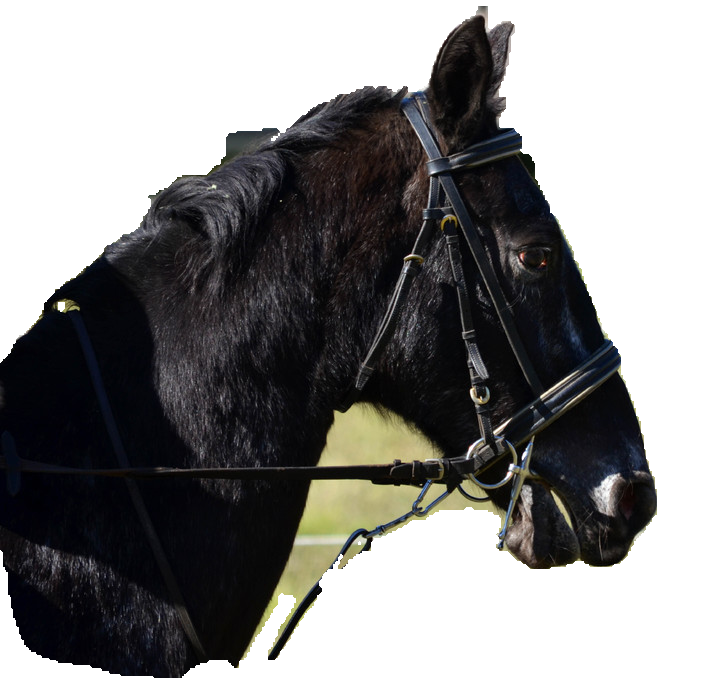

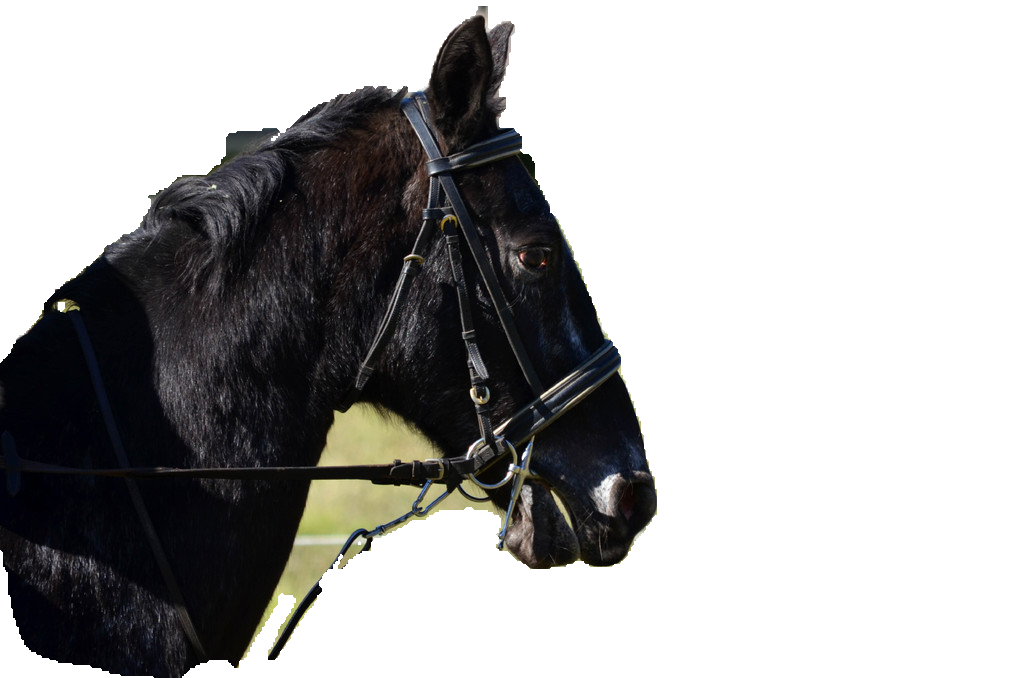

In [8]:
if subject_rows:
    sample = subject_rows[0]
    display(Image.open(REPO_ROOT / sample['crop_path']))
    if sample['isolated_path']:
        display(Image.open(REPO_ROOT / sample['isolated_path']))

## Step 5: Generate Line Diagrams

In [ ]:
run_stage('generate_line_diagrams.py')

diagram_attempts_path = REPO_ROOT / 'processed' / 'silver' / 'qa' / 'line_diagram_attempts.ndjson'
diagram_attempt_rows = load_ndjson(diagram_attempts_path)
diagram_attempt_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/generate_line_diagrams.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


## Step 6: Validate And Retry Diagrams

In [11]:
run_stage('validate_and_retry_diagrams.py')

validated_path = REPO_ROOT / 'processed' / 'silver' / 'qa' / 'validated_diagrams.ndjson'
validated_rows = load_ndjson(validated_path)
validated_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/validate_and_retry_diagrams.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'category': 'Horse',
  'diagram_attempt': 5,
  'diagram_generator_backend': {'execution_mode': 'heuristic_emulation',
   'inference_params': {'blur_radius': 0.8, 'threshold': 78},
   'model_backend': 'local',
   'model_name': 'informative_drawings',
   'model_version_or_checkpoint': 'heuristic-emulation-v1'},
  'diagram_path': 'processed/silver/diagrams/Horse/000058c0d54bd325_attempt05.png',
  'diagram_validation_score': 0.0,
  'diagram_validation_status': 'rejected',
  'lineage': {'diagram_attempt_count': 4,
   'subject_sample_id': '000058c0d54bd325'},
  'opencv_flags': ['low_foreground_ratio',
   'too_many_components',
   'too_many_small_contours'],
  'sample_id': '000058c0d54bd325',
  'selected_for_gold': False,
  'selection_rank': None,
  'semantic_validator_model': 'qwen2.5vl:7b',
  'semantic_validator_reason': 'skipped semantic validation because OpenCV pre-screen failed',
  'subcategory': 'horse'},
 {'angle_bucket': 'front_right_3q',
  'catego

## Step 7: Select Final By Angle

In [12]:
run_stage('select_final_by_angle.py')

selected_path = REPO_ROOT / 'processed' / 'silver' / 'qa' / 'selected_diagrams.ndjson'
selected_rows = load_ndjson(selected_path)
selected_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/select_final_by_angle.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[]

In [13]:
run_stage('extract_trajectories.py')

gold_path = REPO_ROOT / 'processed' / 'gold' / 'ndjson' / 'gold_samples.ndjson'
run_stage('export_gold_ndjson.py')
gold_rows = load_ndjson(gold_path)
if gold_rows:
    first = gold_rows[0]
    display(SVG(filename=str(REPO_ROOT / first['gold_refs']['svg_path'])))
    first['trajectory']

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/extract_trajectories.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/export_gold_ndjson.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


## Step 8: Generate Dataset Report

In [14]:
run_stage('generate_dataset_report.py')

report_json = REPO_ROOT / 'artifacts' / 'reports' / 'dataset_report.json'
report_md = REPO_ROOT / 'artifacts' / 'reports' / 'dataset_report.md'
print(report_json.read_text(encoding='utf-8'))
print('\n---\n')
print(report_md.read_text(encoding='utf-8'))

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/generate_dataset_report.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
{
  "accepted_diagrams": 0,
  "angles": {},
  "bronze_accepted": 752,
  "bronze_curated": 2497,
  "categories": {},
  "generated_at": "2026-04-02T03:19:14.149533+00:00",
  "subcategories": {},
  "total_records": 0,
  "validated_diagrams": 752
}

---

# Dataset Report
- Generated: 2026-04-02T03:19:14.149533+00:00
- Bronze curated: 2497
- Bronze accepted: 752
- Validated diagrams: 752
- Accepted diagrams: 0
- Final gold samples: 0
